## IMPORTS

In [1]:
import os
import torch
import pickle

import numpy as np
import torch.nn as nn
import scipy.sparse as sp
import matplotlib.pyplot as plt

from tqdm import tqdm
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neighbors import kneighbors_graph, NearestNeighbors

from cloudforger.core.splits import train_val_test_indices


DATA = "/Users/qp252676/Desktop/point-process-tda/data/thomas/clouds.pkl"
with open(DATA, "rb") as f:
    clouds = pickle.load(f)

n_points = np.array([r["n_points"] for r in clouds])
params = np.array([[r["params"][k] for k in
                    ("parent_intensity","mean_offspring","cluster_scale")]
                   for r in clouds])
param_names = ["parent_intensity","mean_offspring","cluster_scale"]

LOG_IDX = [0, 1, 2]

def fwd_y(Y):
    Z = Y.copy().astype(np.float64)
    Z[:, LOG_IDX] = np.log10(Z[:, LOG_IDX])
    return Z
def inv_y(Z):
    Y = Z.copy()
    Y[:, LOG_IDX] = 10.0 ** Y[:, LOG_IDX]
    return Y


## CONSTRUCT KNN GRAPH

In [2]:
def knn_graph(points, k, weighted=False, sigma=None):
    mode = "distance" if weighted else "connectivity"
    A = kneighbors_graph(points, n_neighbors=k, mode=mode, include_self=False)
    if weighted:
        s = sigma if sigma is not None else np.median(A.data)
        A.data = np.exp(-(A.data**2) / (2 * s**2))
    A = A.maximum(A.T)          # union symmetrization
    return A.tocsr()

pts = clouds[0]["points"]
A = knn_graph(pts, k=3)
print(A.shape, A.nnz, "avg degree", A.nnz / A.shape[0])

(264, 264) 988 avg degree 3.742424242424242


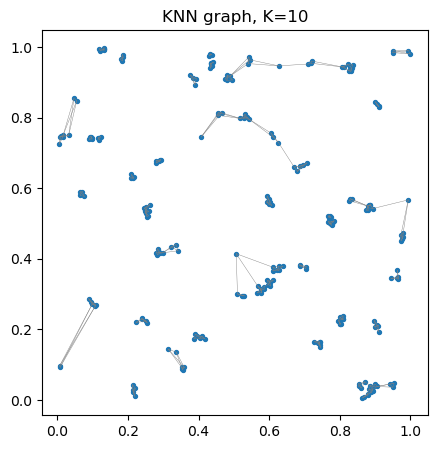

In [3]:
coo = sp.triu(A).tocoo()
plt.figure(figsize=(5,5))
for i, j in zip(coo.row, coo.col):
    plt.plot(pts[[i,j],0], pts[[i,j],1], "-", lw=0.3, color="gray")
plt.scatter(pts[:,0], pts[:,1], s=8)
plt.gca().set_aspect("equal"); plt.title("KNN graph, K=10"); plt.show()

## LAPLACIAN

n components ≈ 33  spectral gap λ2 = 0.0


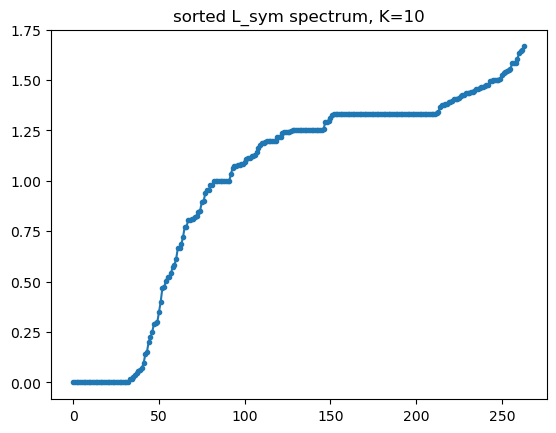

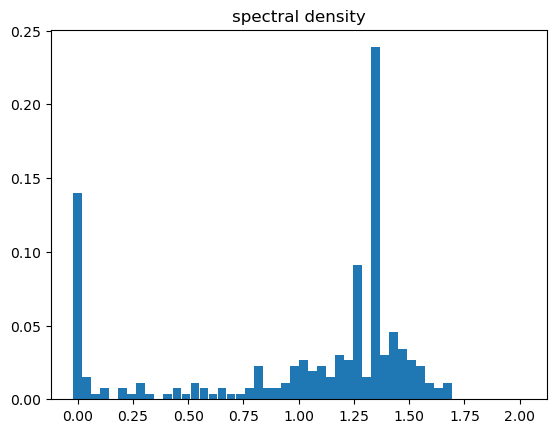

In [4]:
def laplacian_spectrum(A):
    deg = np.asarray(A.sum(1)).ravel()
    dinv = np.zeros_like(deg); nz = deg > 0
    dinv[nz] = 1.0 / np.sqrt(deg[nz])
    Dinv = sp.diags(dinv)
    L = sp.eye(A.shape[0]) - Dinv @ A @ Dinv
    L = ((L + L.T) * 0.5)                      # kill numerical asymmetry
    ev = np.linalg.eigvalsh(L.toarray())      # n<=~1200, dense is fine & robust
    return np.clip(np.sort(ev), 0, 2)

def spectral_hist(ev, B=50):
    h, _ = np.histogram(ev, bins=B, range=(0, 2), density=False)
    return h / h.sum()                        # length B, sums to 1

ev = laplacian_spectrum(A)
print("n components ≈", int(np.sum(ev < 1e-8)), " spectral gap λ2 =", ev[1])
plt.plot(ev, marker="."); plt.title("sorted L_sym spectrum, K=10"); plt.show()
plt.bar(np.linspace(0,2,50), spectral_hist(ev, 50), width=2/50); plt.title("spectral density"); plt.show()

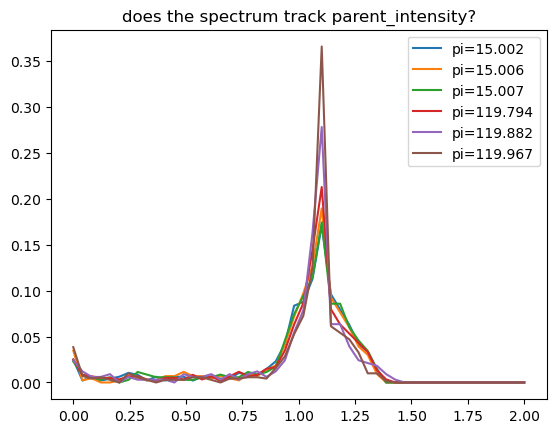

In [5]:
order = np.argsort(params[:, param_names.index("parent_intensity")])
for idx in list(order[:3]) + list(order[-3:]):
    ev = laplacian_spectrum(knn_graph(clouds[idx]["points"], 10))
    plt.plot(np.linspace(0,2,50), spectral_hist(ev,50),
             label=f"pi={params[idx,0]:.3f}")
plt.legend(); plt.title("does the spectrum track parent_intensity?"); plt.show()


## K-GRID

In [6]:
K_GRID = [3, 5, 8, 12, 20, 30, 50]
GRID = np.linspace(0, 2, 128)

CACHE = "/Users/qp252676/Desktop/point-process-tda/data/thomas/knn_lap_cnn.npz"

def spectral_cdf(ev, grid=GRID):
    return np.searchsorted(np.sort(ev), grid, side="right") / len(ev)   # length 128, monotone

def cloud_feature_matrix(points, k_grid=K_GRID, grid=GRID):
    rows = []
    for k in k_grid:
        k = min(k, len(points) - 1)
        ev = laplacian_spectrum(knn_graph(points, k))
        rows.append(spectral_cdf(ev, grid))
    return np.vstack(rows)            # (len(k_grid), 128)

def aux_features(points, k=10):
    d, _ = NearestNeighbors(n_neighbors=k+1).fit(points).kneighbors(points)
    d = d[:, 1:]
    return np.array([len(points),
                     d.mean(), d.std(), np.median(d[:, -1]),
                     d[:, 0].mean()])          # n, mean kNN dist, etc.


# X/AUX are expensive (eigendecomposition per cloud/K) so they're cached to disk.
# Y is just `params` reshuffled -- cheap, and must always reflect the current
# param_names, so it is never cached and is rebuilt fresh every run.
if os.path.exists(CACHE):
    print("loading cached features from", CACHE)
    _d = np.load(CACHE)
    X, AUX = _d["X"], _d["AUX"]
else:
    X = np.stack([cloud_feature_matrix(r["points"]) for r in tqdm(clouds)])   # (7000, 7, 128)
    AUX = np.stack([aux_features(r["points"]) for r in clouds])        # (7000, 5)
    np.savez(CACHE, X=X, AUX=AUX)

Y = params.copy()                                                             # (7000, len(param_names))

print(X.shape, AUX.shape, Y.shape)


loading cached features from /Users/qp252676/Desktop/point-process-tda/data/thomas/knn_lap_cnn.npz
(7000, 7, 128) (7000, 5) (7000, 3)


## BUILD DATASET

In [7]:
VIHRS_SEED = 9371   # align our split to this vihrs_checkpointed run for a leak-free comparison

tr, va, te = train_val_test_indices(len(X), seed=VIHRS_SEED)   # canonical (0.7, 0.15, 0.15) split

Xmu, Xsd = X[tr].mean(0, keepdims=True), X[tr].std(0, keepdims=True) + 1e-8
Amu, Asd = AUX[tr].mean(0), AUX[tr].std(0) + 1e-8
Zt = fwd_y(Y); Ymu, Ysd = Zt[tr].mean(0), Zt[tr].std(0) + 1e-8

def prep(i):
    return ((X[i]-Xmu)/Xsd, (AUX[i]-Amu)/Asd, (fwd_y(Y[i:i+1] if np.ndim(i)==0 else Y[i])-Ymu)/Ysd)

def make_loader(sel, bs, shuffle):
    xs = torch.tensor(((X[sel]-Xmu)/Xsd), dtype=torch.float32)
    as_ = torch.tensor(((AUX[sel]-Amu)/Asd), dtype=torch.float32)
    ys = torch.tensor(((fwd_y(Y[sel])-Ymu)/Ysd), dtype=torch.float32)
    return DataLoader(TensorDataset(xs, as_, ys), batch_size=bs, shuffle=shuffle)

dl_tr = make_loader(tr, 128, True)
dl_va = make_loader(va, 256, False)
dl_te = make_loader(te, 256, False)


## MODEL

In [8]:
class SpectralCNN(nn.Module):
    def __init__(self, n_k=7, n_aux=5, n_out=3, w=48, d_embed=96, p=0.35):
        super().__init__()
        self.n_k, self.C = n_k, 2 * w
        g = n_k
        self.conv = nn.Sequential(
            nn.Conv1d(n_k, n_k*w, 5, padding=2, groups=g), nn.BatchNorm1d(n_k*w), nn.GELU(),
            nn.Conv1d(n_k*w, n_k*w, 5, padding=2, groups=g), nn.BatchNorm1d(n_k*w), nn.GELU(),
            nn.MaxPool1d(2),
            nn.Conv1d(n_k*w, n_k*2*w, 3, padding=1, groups=g), nn.BatchNorm1d(n_k*2*w), nn.GELU(),
            nn.AdaptiveAvgPool1d(1),
        )
        # groups=n_k keeps every K's channels independent through the whole
        # conv stack, so the pooled+flattened output is already
        # [branch_0 feats | branch_1 feats | ... | branch_{n_k-1} feats] --
        # i.e. the per-K outputs concatenated. Project that down to a
        # fixed-size embedding.
        #
        # NOTE: tried d_embed=64 + dropout here + weight_decay=1e-3 as a
        # regularization pass (recommendation 1). Isolation experiment across
        # 3 runs (this config, d_embed=64+dropout @ wd=1e-3, and
        # d_embed=64+dropout @ wd=3e-4) showed no clean win -- differences
        # were all ~0.01-0.02 R2 / a few % MAE, comparable to the run-to-run
        # noise from unseeded init/shuffling (see repeat-run check below).
        # This config (d_embed=96, no embedding dropout) is the only one of
        # the three that beat GBM on 2/3 params, so keeping it as the
        # baseline. Next step: per-K attention/gating (structural, not a
        # regularization knob) rather than further hyperparameter search here.
        self.proj = nn.Sequential(
            nn.Linear(n_k * self.C, d_embed),
            nn.LayerNorm(d_embed),
            nn.GELU(),
        )
        self.aux  = nn.Sequential(nn.Linear(n_aux, 32), nn.GELU())
        self.head = nn.Sequential(
            nn.Linear(d_embed + 32, 128), nn.GELU(), nn.Dropout(p),
            nn.Linear(128, n_out),
        )

    def encode(self, x):                    # x: (B, n_k, 128)
        h = self.conv(x).squeeze(-1)        # (B, n_k*C) -- concatenated per-K feats
        return self.proj(h)                 # (B, d_embed)  <- the embedding

    def forward(self, x, a):
        emb = self.encode(x)
        return self.head(torch.cat([emb, self.aux(a)], dim=1))

## TRAIN LOOP

In [9]:
dev = "mps"
SEED = 0
torch.manual_seed(SEED)
net = SpectralCNN(w=32).to(dev)
opt = torch.optim.AdamW(net.parameters(), lr=1e-3, weight_decay=3e-4)
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=60)
lossf = nn.SmoothL1Loss()

hist = {"tr": [], "va": [], "lr": []}
best, best_state, best_ep, patience, bad = 1e9, None, 0, 20, 0
for epoch in range(150):
    net.train(); ts = tn = 0
    for x, a, y in dl_tr:
        x, a, y = x.to(dev), a.to(dev), y.to(dev)
        opt.zero_grad()
        loss = lossf(net(x, a), y)
        loss.backward(); opt.step()
        ts += loss.item() * len(x); tn += len(x)
    sch.step()

    net.eval(); vs = vn = 0
    with torch.no_grad():
        for x, a, y in dl_va:
            x, a, y = x.to(dev), a.to(dev), y.to(dev)
            vs += lossf(net(x, a), y).item() * len(x); vn += len(x)
    tr_l, va_l = ts / tn, vs / vn
    hist["tr"].append(tr_l); hist["va"].append(va_l); hist["lr"].append(sch.get_last_lr()[0])

    if va_l < best - 1e-4:
        best, best_state, best_ep, bad = va_l, {k: v.cpu().clone() for k, v in net.state_dict().items()}, epoch, 0
    else:
        bad += 1
        if bad >= patience: break
    print(epoch, round(tr_l, 4), round(va_l, 4))
net.load_state_dict(best_state)
print("best epoch", best_ep, "val", round(best, 4), "seed", SEED)
print("n params", sum(p.numel() for p in net.parameters()))

0 0.2078 0.1344


1 0.1046 0.1086


2 0.0949 0.0914


3 0.0856 0.0856


4 0.0831 0.0813


...

38 0.0384 0.0741


39 0.0393 0.071


40 0.0364 0.074


41 0.0355 0.0734


best epoch 22 val 0.0684 seed 0
n params 143043


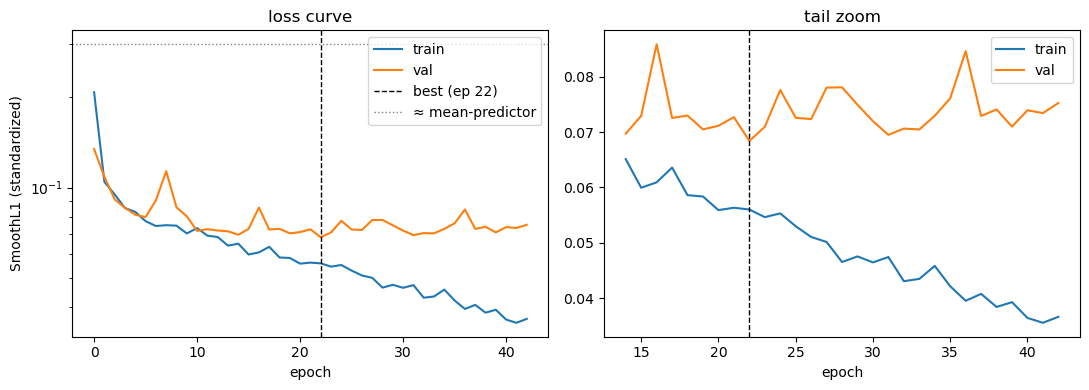

In [10]:
ep = np.arange(len(hist["tr"]))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(ep, hist["tr"], label="train")
ax[0].plot(ep, hist["va"], label="val")
ax[0].axvline(best_ep, ls="--", c="k", lw=1, label=f"best (ep {best_ep})")
ax[0].axhline(0.30, ls=":", c="gray", lw=1, label="≈ mean-predictor")
ax[0].set_yscale("log"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("SmoothL1 (standardized)")
ax[0].legend(); ax[0].set_title("loss curve")

k = max(1, len(ep) // 3)                       # zoom on the tail
ax[1].plot(ep[k:], hist["tr"][k:], label="train")
ax[1].plot(ep[k:], hist["va"][k:], label="val")
ax[1].axvline(best_ep, ls="--", c="k", lw=1)
ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].set_title("tail zoom")
plt.tight_layout(); plt.show()

## EVALUATE

In [11]:
net.eval(); preds = []
with torch.no_grad():
    for x, a, y in dl_te:
        preds.append(net(x.to(dev), a.to(dev)).cpu().numpy())
Zhat = np.concatenate(preds) * Ysd + Ymu
Yhat = inv_y(Zhat); Ytrue = Y[te]

for j, name in enumerate(param_names):
    print(f"{name:18s} R2 {r2_score(Ytrue[:,j], Yhat[:,j]):.3f}   "
          f"MAE {mean_absolute_error(Ytrue[:,j], Yhat[:,j]):.4g}")

Xtr_f = np.hstack([X[tr].reshape(len(tr), -1), AUX[tr]])
Xte_f = np.hstack([X[te].reshape(len(te), -1), AUX[te]])
Ztr, Zte = fwd_y(Y[tr]), fwd_y(Y[te])

print(f"{'param':18s} {'CNN R2':>8s} {'GBM R2':>8s} {'CNN MAE':>10s} {'GBM MAE':>10s}")
for j, name in enumerate(param_names):
    m = HistGradientBoostingRegressor(max_iter=400).fit(Xtr_f, Ztr[:, j])
    zpred = m.predict(Xte_f)
    gbm = zpred if j not in LOG_IDX else 10.0 ** zpred
    tru = Y[te][:, j]
    print(f"{name:18s} {r2_score(tru, Yhat[:,j]):8.3f} {r2_score(tru, gbm):8.3f} "
          f"{mean_absolute_error(tru, Yhat[:,j]):10.4g} {mean_absolute_error(tru, gbm):10.4g}")


parent_intensity   R2 0.772   MAE 9.289
mean_offspring     R2 0.835   MAE 1.999
cluster_scale      R2 0.883   MAE 0.003951
param                CNN R2   GBM R2    CNN MAE    GBM MAE


parent_intensity      0.772    0.738      9.289      9.936


mean_offspring        0.835    0.852      1.999      1.923


cluster_scale         0.883    0.891   0.003951   0.003868


## VS VIHRS

In [12]:
import json, glob

# sanity check: our test split must not overlap the vihrs test split we're
# comparing against, or this whole comparison is leakage, not a result.
vihrs_dirs = sorted(glob.glob(
    "/Users/qp252676/Desktop/point-process-tda/results/thomas/raw/vihrs_checkpointed/seed_*"))

vihrs_metrics = {}
for d in vihrs_dirs:
    seed = int(d.rsplit("seed_", 1)[1])
    with open(f"{d}/metrics.json") as f:
        vihrs_metrics[seed] = json.load(f)

matched = vihrs_metrics[VIHRS_SEED]
_, _, te_vihrs = train_val_test_indices(len(X), seed=VIHRS_SEED)
overlap = len(set(tr.tolist()) & set(te_vihrs.tolist()))
assert overlap == 0, f"{overlap} of our train indices leak into vihrs seed {VIHRS_SEED}'s test set!"
assert set(te.tolist()) == set(te_vihrs.tolist()), "our test split doesn't match vihrs's -- re-run BUILD DATASET"
print(f"leakage check passed: 0 overlap, {len(te)} test clouds shared exactly with vihrs seed {VIHRS_SEED}")

def log_mae_rmse(pred, true):
    # NATURAL log -- must match cloudforger.core.metrics.one_estimator_metrics
    # (log_errors = np.log(e) - np.log(t)), which is how the vihrs metrics.json
    # we compare against below was scored. Using log10 here made our
    # log_mae/log_rmse ~ln(10)=2.303x smaller than vihrs's, i.e. a spurious win.
    le = np.log(pred) - np.log(true)
    return np.abs(le).mean(), np.sqrt((le**2).mean())

# ours, on the exact same 1050 held-out clouds vihrs seed_9371 was scored on
ours = {}
for j, name in enumerate(param_names):
    lmae, lrmse = log_mae_rmse(Yhat[:, j], Ytrue[:, j])
    ours[name] = dict(
        mae=mean_absolute_error(Ytrue[:, j], Yhat[:, j]),
        rmse=float(np.sqrt(np.mean((Yhat[:, j] - Ytrue[:, j]) ** 2))),
        log_mae=lmae, log_rmse=lrmse,
    )

# vihrs, averaged across its 5 seeds (mean +/- std) for context, plus the
# single seed_9371 run that's the true apples-to-apples comparison
vihrs_seeds = sorted(vihrs_metrics)
print(f"\n{'param':16s} {'metric':8s} {'CNN (ours)':>12s} {'vihrs@9371':>12s} {'vihrs mean±std (n=5)':>22s}  winner")
for name in param_names:
    for metric in ("mae", "rmse", "log_mae", "log_rmse"):
        vals = np.array([vihrs_metrics[s][name][metric] for s in vihrs_seeds])
        ours_v = ours[name][metric]
        matched_v = matched[name][metric]
        winner = "CNN" if ours_v < matched_v else "vihrs"
        print(f"{name:16s} {metric:8s} {ours_v:12.4g} {matched_v:12.4g} "
              f"{vals.mean():10.4g} ± {vals.std():<8.2g}  {winner}")


leakage check passed: 0 overlap, 1050 test clouds shared exactly with vihrs seed 9371

param            metric     CNN (ours)   vihrs@9371   vihrs mean±std (n=5)  winner
parent_intensity mae             9.289        8.489      8.335 ± 0.17      vihrs
parent_intensity rmse            13.15        11.76      11.67 ± 0.13      vihrs
parent_intensity log_mae        0.2062         0.19     0.1902 ± 0.0022    vihrs
parent_intensity log_rmse       0.2785       0.2506     0.2496 ± 0.0024    vihrs
mean_offspring   mae             1.999        1.969       2.01 ± 0.037     vihrs
mean_offspring   rmse            3.414        3.223      3.223 ± 0.04      vihrs
mean_offspring   log_mae        0.1862       0.1782     0.1754 ± 0.0023    vihrs
mean_offspring   log_rmse       0.2708       0.2442     0.2395 ± 0.0029    vihrs
cluster_scale    mae          0.003951      0.00332   0.003156 ± 0.00011   vihrs
cluster_scale    rmse         0.006923     0.006004   0.005653 ± 0.00024   vihrs
cluster_scale    log

## BASELINES

In [13]:
Xtr_f = np.hstack([X[tr].reshape(len(tr), -1), AUX[tr]])
Xte_f = np.hstack([X[te].reshape(len(te), -1), AUX[te]])
for j, name in enumerate(param_names):
    m = HistGradientBoostingRegressor(max_iter=400).fit(Xtr_f, fwd_y(Y[tr])[:, j])
    p = inv_y(np.column_stack([m.predict(Xte_f)]*5))[:, 0] if j in LOG_IDX else m.predict(Xte_f)
    # simpler: just predict in transformed space then invert that column
